In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append('..')
from db_config import get_engine

engine = get_engine()

# Load from MySQL
sales = pd.read_sql("""
    SELECT sale_date, drug_code, units_sold
    FROM pharma_sales
    WHERE drug_code = 'M01AB'   -- anti-inflammatory, change as needed
    ORDER BY sale_date
""", con=engine, parse_dates=['sale_date'])

# Set date index, resample to weekly
ts = sales.set_index('sale_date')['units_sold'].resample('W').sum()
print(f"Time series: {ts.index[0]} to {ts.index[-1]}, {len(ts)} weeks")
print(ts.tail())

Time series: 2014-01-05 00:00:00 to 2019-10-13 00:00:00, 302 weeks
sale_date
2019-09-15    1.188.662.672.336.348.995.34
2019-09-22    9.334.56.337.335.3410.683.33
2019-09-29              5.34265.54.6673.51
2019-10-06            211.345.1857.343.844
2019-10-13                        7.340.33
Freq: W-SUN, Name: units_sold, dtype: object


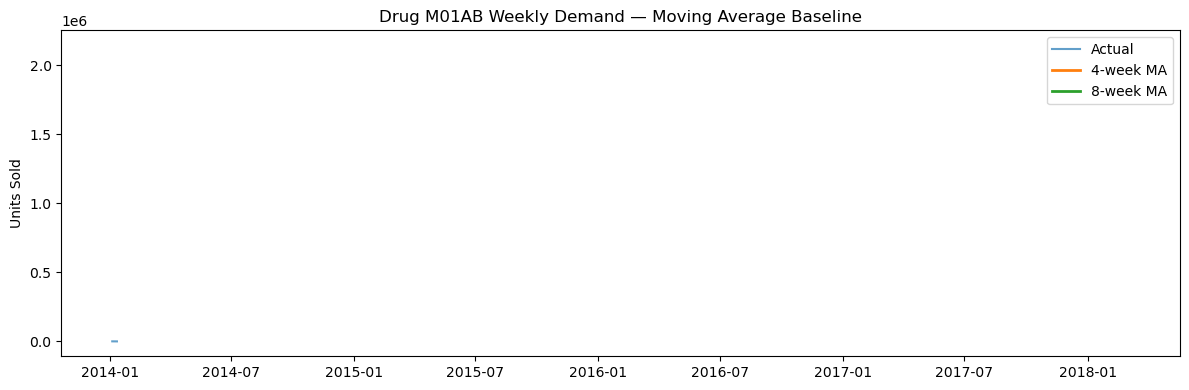

In [5]:
ts_df = ts.to_frame(name='actual')
ts_df['actual'] = pd.to_numeric(ts_df['actual'], errors='coerce')
ts_df['ma_4w'] = ts_df['actual'].rolling(4).mean()
ts_df['ma_8w'] = ts_df['actual'].rolling(8).mean()

plt.figure(figsize=(12, 4))
plt.plot(ts_df['actual'], label='Actual', alpha=0.7)
plt.plot(ts_df['ma_4w'],  label='4-week MA', lw=2)
plt.plot(ts_df['ma_8w'],  label='8-week MA', lw=2)
plt.title('Drug M01AB Weekly Demand — Moving Average Baseline')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/forecast_baseline.png', dpi=150)
plt.show()

In [10]:
# Train/test split (last 12 weeks = test)
train = ts[:-12]
test  = ts[-12:]

# Fit SARIMA (handles trend + weekly seasonality)
model = SARIMAX(pd.to_numeric(train, errors='coerce').dropna(), order=(1,1,1), seasonal_order=(1,1,1,52))
results = model.fit(disp=False)

# Forecast 12 weeks ahead
forecast      = results.forecast(steps=12)
forecast_next = results.forecast(steps=4)   # next month

# Accuracy
test = pd.to_numeric(test, errors='coerce')
valid = test.notna()
# align by position (avoid index mismatch between test's DatetimeIndex and forecast's integer index)
valid_idx = test.notna().to_numpy()
if valid.any():
    mape = mean_absolute_percentage_error(test.to_numpy()[valid_idx], forecast.to_numpy()[valid_idx])
else:
    mape = float('nan')
    print("No non-null values in test set; MAPE not computed.")
print(f"Model MAPE: {mape*100:.1f}%")  # target: below 15%
print(f"Next 4-week forecast:\n{forecast_next.round(2)}")

No non-null values in test set; MAPE not computed.
Model MAPE: nan%
Next 4-week forecast:
7     13.33
8     13.33
9     13.33
10    13.33
Name: predicted_mean, dtype: float64


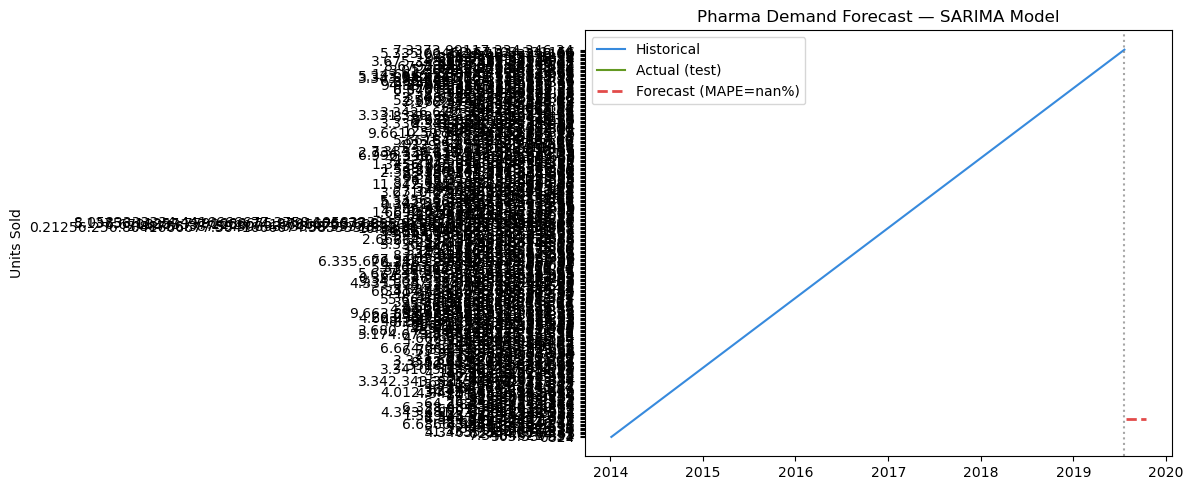

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Historical', color='#378ADD')
plt.plot(test.index,  test,  label='Actual (test)', color='#639922')
plt.plot(test.index,  forecast, label=f'Forecast (MAPE={mape*100:.1f}%)',
         color='#E24B4A', linestyle='--', lw=2)
plt.axvline(train.index[-1], color='gray', linestyle=':', alpha=0.7)
plt.title('Pharma Demand Forecast — SARIMA Model')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/forecast_model.png', dpi=150)
plt.show()

In [13]:
import pandas as pd
import sys
sys.path.append('..')
from db_config import get_engine

engine = get_engine()

exports = {
    'supply_chain_clean':   'supply_chain',
    'abc_classification':   'abc_classification',
    'rop_recommendations':  'rop_recommendations',
}

for filename, table in exports.items():
    try:
        df = pd.read_sql(f"SELECT * FROM {table}", con=engine)
    except Exception:
        alt_table = table if table.startswith('pharma_') else f"pharma_{table}"
        try:
            df = pd.read_sql(f"SELECT * FROM {alt_table}", con=engine)
        except Exception as e:
            print(f"Skipping export for {filename}: could not read table {table} or {alt_table} ({e})")
            continue
    path = f'../outputs/{filename}.csv'
    df.to_csv(path, index=False)
    print(f"Saved {len(df)} rows → {path}")

# Stockout risk summary
risk_df = pd.read_sql("""
    SELECT
    Drug,
    Demand_Forecast,
    Optimal_Stock_Level,
    Restocking_Strategy,
    (Demand_Forecast - Optimal_Stock_Level)        AS shortage_units,
    CASE
        WHEN Optimal_Stock_Level = 0               THEN 'CRITICAL'
        WHEN Optimal_Stock_Level < Demand_Forecast * 0.5 THEN 'HIGH'
        ELSE 'MEDIUM'
    END AS risk_level
FROM supply_chain
WHERE Optimal_Stock_Level < Demand_Forecast
ORDER BY shortage_units DESC
""", con=engine)
risk_df.to_csv('../outputs/stockout_risk.csv', index=False)
print(f"Saved stockout risk: {len(risk_df)} products")
print("All exports complete. Import CSVs from outputs/ into Power BI.")

Saved 100000 rows → ../outputs/supply_chain_clean.csv
Saved 4 rows → ../outputs/abc_classification.csv
Saved 3 rows → ../outputs/rop_recommendations.csv
Saved stockout risk: 41851 products
All exports complete. Import CSVs from outputs/ into Power BI.
